In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
# e-mail classification
# subject formality score -> resmiyet seviyesi
# sender relationship score -> yakınlık (akraba) seviyesi
# e-mail type -> 0 = personel, 1= work 

In [20]:
df = pd.read_csv("9-email_classification_svm.csv")

In [21]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [22]:
df.describe()

,subject_formality_score,sender_relationship_score,email_type
count,1000.000000,1000.000000,1000.000000
mean,-1.009046,-0.006300,0.498000
std,0.654219,1.059501,0.500246
min,-3.532770,-2.218219,0.000000
25%,-1.252867,-1.006076,0.000000
50%,-0.994760,0.439233,0.000000
75%,-0.754839,0.994943,1.000000
max,2.180933,1.699497,1.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [24]:
df.isnull().sum()

subject_formality_score      0
sender_relationship_score    0
email_type                   0
dtype: int64

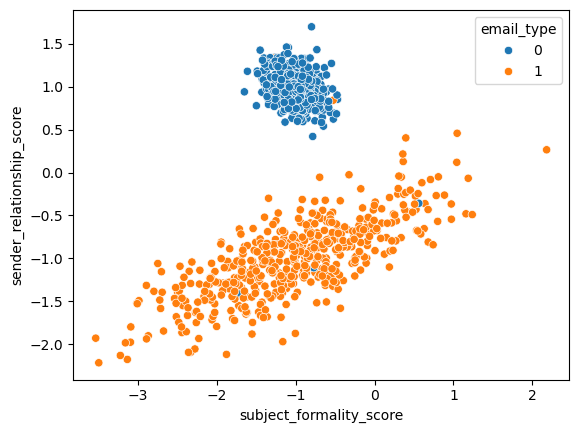

In [25]:
sns.scatterplot(x = df["subject_formality_score"], y = df["sender_relationship_score"],hue = df["email_type"])
plt.show()

In [26]:
df["email_type"].value_counts()

email_type
0    502
1    498
Name: count, dtype: int64

In [27]:
X = df.drop("email_type", axis = 1)
y = df["email_type"]

In [28]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=15)

In [31]:
X_train

,subject_formality_score,sender_relationship_score
846,-1.076655,0.943601
969,-1.062554,1.148473
191,-0.904298,1.049447
711,-1.283609,-1.171544
967,-1.097239,1.388281
...,...,...
887,-1.153241,1.241387
645,-0.964472,1.235402
908,-0.862866,1.110327
757,-1.124572,0.967717


In [32]:
from sklearn.svm import SVC

In [33]:
svc = SVC(kernel="linear")

In [36]:
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [37]:
svc.coef_

array([[ 0.60318833, -1.91645213]])

In [38]:
y_pred = svc.predict(X_test)

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

In [44]:
print("classification report: \n", classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

classification report: 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       117
           1       1.00      0.99      1.00       133

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

[[117   0]
 [  1 132]]


In [47]:
rbf = SVC(kernel = "rbf")
rbf.fit(X_train, y_train)
y_pred = rbf.predict(X_test)
print("classification report: \n", classification_report(y_pred,y_test))
print(confusion_matrix(y_pred, y_test))

classification report: 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       117
           1       1.00      0.99      1.00       133

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

[[117   0]
 [  1 132]]


# new dataset

In [48]:
df = pd.read_csv("9-loan_risk_svm.csv")

In [50]:
# loan risk analysis

In [51]:
df.head()

,credit_score_fluctuation,recent_transaction_volume,loan_risk
0,-1.439860,1.283010,1
1,-0.276571,-1.232382,0
2,1.312047,0.955097,1
3,1.020706,0.089485,0
4,1.513729,0.580520,1


In [52]:
df.describe()

,credit_score_fluctuation,recent_transaction_volume,loan_risk
count,1000.000000,1000.000000,1000.000000
mean,-0.024200,-0.018748,0.504000
std,1.257080,1.222329,0.500234
min,-3.562160,-2.641815,0.000000
25%,-1.001007,-0.995190,0.000000
50%,-0.105200,-0.142727,1.000000
75%,1.007451,0.964210,1.000000
max,2.984892,3.338639,1.000000


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   credit_score_fluctuation   1000 non-null   float64
 1   recent_transaction_volume  1000 non-null   float64
 2   loan_risk                  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [54]:
df.isnull().sum()

credit_score_fluctuation     0
recent_transaction_volume    0
loan_risk                    0
dtype: int64

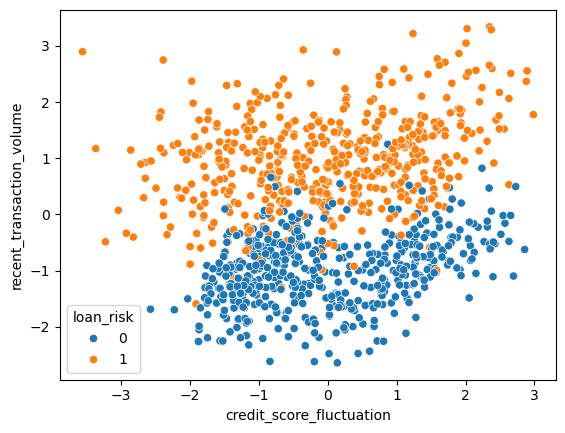

In [58]:
sns.scatterplot(x = df["credit_score_fluctuation"], y =df["recent_transaction_volume"], hue = df["loan_risk"])
plt.show()

In [59]:
X = df.drop("loan_risk", axis = 1)
y = df["loan_risk"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [71]:
linear = SVC(kernel = "linear")
linear.fit(X_train, y_train)
y_pred3 = linear.predict(X_test)
print(classification_report(y_pred3, y_test))
print(confusion_matrix(y_pred3, y_test))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       118
           1       0.93      0.91      0.92       132

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[109   9]
 [ 12 120]]


In [72]:
rbf = SVC(kernel = "rbf")
rbf.fit(X_train, y_train)
y_pred4 = rbf.predict(X_test)
print(classification_report(y_pred4, y_test))
print(confusion_matrix(y_pred4, y_test))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       124
           1       0.91      0.94      0.93       126

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[113  11]
 [  8 118]]


In [74]:
poly = SVC(kernel = "poly")
poly.fit(X_train, y_train)
y_pred5 = poly.predict(X_test)
print(classification_report(y_pred5, y_test))
print(confusion_matrix(y_pred5, y_test))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       115
           1       0.94      0.90      0.92       135

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[107   8]
 [ 14 121]]


In [75]:
sigm = SVC(kernel = "sigmoid")
sigm.fit(X_train, y_train)
y_pred6 = sigm.predict(X_test)
print(classification_report(y_pred6, y_test))
print(confusion_matrix(y_pred6, y_test))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       118
           1       0.84      0.83      0.84       132

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250

[[ 98  20]
 [ 23 109]]


In [77]:
#hyperparameter tuning

In [78]:
SVC()

SVC()

In [79]:
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

In [80]:
from sklearn.model_selection import GridSearchCV

In [81]:
grid = GridSearchCV(estimator = SVC(), param_grid = param_grid, cv = 5)

In [82]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'linear']})

In [83]:
grid.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [84]:
y_pred7 = grid.predict(X_test)
print(classification_report(y_pred7, y_test))
print(confusion_matrix(y_pred7, y_test))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       122
           1       0.92      0.93      0.93       128

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[112  10]
 [  9 119]]


# sismic activities
# 3D örnek

In [108]:
# underground_wave_energy -> yeraltındaki dalga enerjisi
# vibration_axis_variation -> titreşim eksen değişimi
# seismic_event_detected -> sismic olay algılandı mı 0: evet, 1: hayır

In [118]:
df = pd.read_csv("9-seismic_activity_svm.csv")

In [119]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [120]:
df.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


In [121]:
df.isnull().sum()

underground_wave_energy     0
vibration_axis_variation    0
seismic_event_detected      0
dtype: int64

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [123]:
df["seismic_event_detected"].value_counts()

seismic_event_detected
0    200
1    200
Name: count, dtype: int64

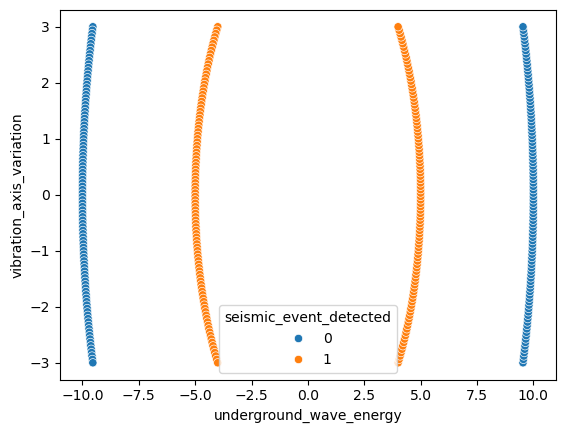

In [124]:
sns.scatterplot( x = df["underground_wave_energy"], y = df["vibration_axis_variation"], hue = df["seismic_event_detected"])
plt.show()

In [125]:
df.columns

Index(['underground_wave_energy', 'vibration_axis_variation',
       'seismic_event_detected'],
      dtype='object')

In [126]:
df["underground_wave_energy **2"] = df["underground_wave_energy"] **2
df["vibration_axis_variation **2"] = df["vibration_axis_variation"] **2
df["underground_wave_energ * vibration_axis_variation"] = (df["underground_wave_energy"] * df["vibration_axis_variation"])

In [127]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected,underground_wave_energy **2,vibration_axis_variation **2,underground_wave_energ * vibration_axis_variation
0,9.539392,-3.000000,0,91.000000,9.000000,-28.618176
1,9.558241,-2.939394,0,91.359963,8.640037,-28.095434
2,9.576669,-2.878788,0,91.712580,8.287420,-27.569197
3,9.594678,-2.818182,0,92.057851,7.942149,-27.039548
4,9.612272,-2.757576,0,92.395776,7.604224,-26.506569


In [128]:
X = df.drop("seismic_event_detected", axis = 1)
y = df["seismic_event_detected"]

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [130]:
X_train

,underground_wave_energy,vibration_axis_variation,underground_wave_energy **2,vibration_axis_variation **2,underground_wave_energ * vibration_axis_variation
135,-9.961312,0.878788,99.227732,0.772268,-8.753880
170,-9.922519,-1.242424,98.456382,1.543618,12.327978
368,-4.872667,-1.121212,23.742883,1.257117,5.463293
77,9.860133,1.666667,97.222222,2.777778,16.433555
12,9.738311,-2.272727,94.834711,5.165289,-22.132526
...,...,...,...,...,...
384,-4.541817,-2.090909,20.628099,4.371901,9.496526
375,-4.755162,-1.545455,22.611570,2.388430,7.348887
133,-9.949874,1.000000,99.000000,1.000000,-9.949874
396,-4.130115,-2.818182,17.057851,7.942149,11.639415


In [131]:
import plotly.express as px

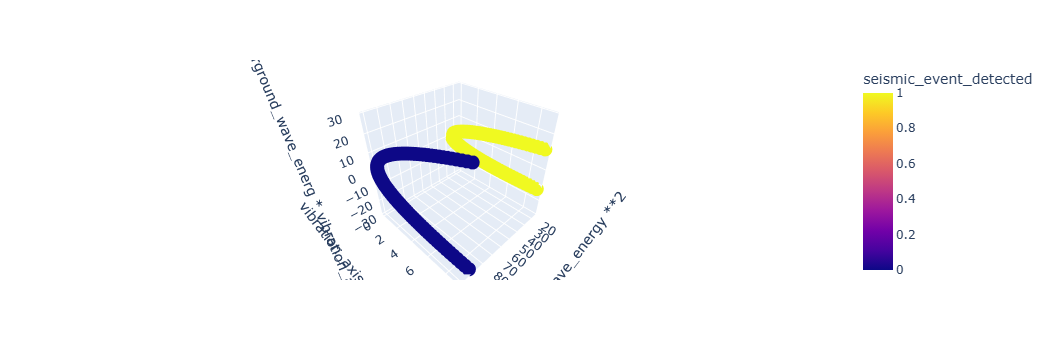

In [134]:
fig = px.scatter_3d(df, x ="underground_wave_energy **2", y = "vibration_axis_variation **2" , z="underground_wave_energ * vibration_axis_variation",
                   color= "seismic_event_detected"
                   )
fig.show()

In [135]:
linear = SVC(kernel = "linear")
linear.fit(X_train, y_train)
y_pred8 = linear.predict(X_test)
print(classification_report(y_pred8, y_test))
print(confusion_matrix(y_pred8, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        52

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[48  0]
 [ 0 52]]


In [139]:
# automatic rbf

In [140]:
df = pd.read_csv("9-seismic_activity_svm.csv")

In [141]:
X = df.drop("seismic_event_detected", axis = 1)
y = df["seismic_event_detected"]

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [148]:
rbf = SVC(kernel = "rbf")
rbf.fit(X_train, y_train)
y_pred10 = rbf.predict(X_test)
print(classification_report(y_pred10, y_test))
print(confusion_matrix(y_pred10, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        52

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[48  0]
 [ 0 52]]
